In [39]:
import numpy as np 
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt

In [40]:
df = pd.read_csv("files/flight_dataset.csv")

In [41]:
df.describe()

,Total_Stops,Price,Date,Month,Year,Dep_hours,Dep_min,Arrival_hours,Arrival_min,Duration_hours,Duration_min
count,10683.000000,10683.000000,10683.000000,10683.000000,10683.0,10683.000000,10683.000000,10683.000000,10683.000000,10683.000000,10683.000000
mean,0.824207,9087.064121,13.508378,4.708602,2019.0,12.490686,24.411214,13.348778,24.690630,10.246560,28.327249
std,0.675199,4611.359167,8.479277,1.164357,0.0,5.748650,18.767980,6.859125,16.506036,8.494988,16.946113
min,0.000000,1759.000000,1.000000,3.000000,2019.0,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,0.000000,5277.000000,6.000000,3.000000,2019.0,8.000000,5.000000,8.000000,10.000000,2.000000,15.000000
50%,1.000000,8372.000000,12.000000,5.000000,2019.0,11.000000,25.000000,14.000000,25.000000,8.000000,30.000000
75%,1.000000,12373.000000,21.000000,6.000000,2019.0,18.000000,40.000000,19.000000,35.000000,15.000000,45.000000
max,4.000000,79512.000000,27.000000,6.000000,2019.0,23.000000,55.000000,23.000000,55.000000,47.000000,55.000000


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Airline         10683 non-null  object
 1   Source          10683 non-null  object
 2   Destination     10683 non-null  object
 3   Total_Stops     10683 non-null  int64 
 4   Price           10683 non-null  int64 
 5   Date            10683 non-null  int64 
 6   Month           10683 non-null  int64 
 7   Year            10683 non-null  int64 
 8   Dep_hours       10683 non-null  int64 
 9   Dep_min         10683 non-null  int64 
 10  Arrival_hours   10683 non-null  int64 
 11  Arrival_min     10683 non-null  int64 
 12  Duration_hours  10683 non-null  int64 
 13  Duration_min    10683 non-null  int64 
dtypes: int64(11), object(3)
memory usage: 1.1+ MB


In [43]:
df.head(5)

,Airline,Source,Destination,Total_Stops,Price,Date,Month,Year,Dep_hours,Dep_min,Arrival_hours,Arrival_min,Duration_hours,Duration_min
0,IndiGo,Banglore,New Delhi,0,3897,24,3,2019,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,2,7662,1,5,2019,5,50,13,15,7,25
2,Jet Airways,Delhi,Cochin,2,13882,9,6,2019,9,25,4,25,19,0
3,IndiGo,Kolkata,Banglore,1,6218,12,5,2019,18,5,23,30,5,25
4,IndiGo,Banglore,New Delhi,1,13302,1,3,2019,16,50,21,35,4,45


In [44]:
df.columns

Index(['Airline', 'Source', 'Destination', 'Total_Stops', 'Price', 'Date',
       'Month', 'Year', 'Dep_hours', 'Dep_min', 'Arrival_hours', 'Arrival_min',
       'Duration_hours', 'Duration_min'],
      dtype='object')

In [45]:
for column in df.columns:
    if df[column].dtype == "object":
        print(f"{8*'*'}\n{column}|{df[column].value_counts()}")

********
Airline|Airline
Jet Airways                          3849
IndiGo                               2053
Air India                            1752
Multiple carriers                    1196
SpiceJet                              818
Vistara                               479
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64
********
Source|Source
Delhi       4537
Kolkata     2871
Banglore    2197
Mumbai       697
Chennai      381
Name: count, dtype: int64
********
Destination|Destination
Cochin       4537
Banglore     2871
Delhi        1265
New Delhi     932
Hyderabad     697
Kolkata       381
Name: count, dtype: int64


In [46]:
df.drop("Year", axis = 1, inplace = True)

In [47]:
df["Duration"] = df["Duration_hours"] * 60 + df["Duration_min"]
df.drop(["Duration_hours", "Duration_min"], axis = 1, inplace = True)

In [48]:
airline_df = pd.get_dummies(df["Airline"], prefix='airline', dtype=float)
df = pd.concat([df, airline_df], axis=1)

source_df = pd.get_dummies(df["Source"], prefix='source', dtype=float)
df = pd.concat([df, source_df], axis=1)

destination_df = pd.get_dummies(df["Destination"], prefix='destination', dtype=float)
df = pd.concat([df, destination_df], axis=1)

df = df.drop("Airline", axis=1)
df = df.drop("Source", axis=1)
df = df.drop("Destination", axis=1)

In [49]:
df.head(5)

,Total_Stops,Price,Date,Month,Dep_hours,Dep_min,Arrival_hours,Arrival_min,Duration,airline_Air Asia,...,source_Chennai,source_Delhi,source_Kolkata,source_Mumbai,destination_Banglore,destination_Cochin,destination_Delhi,destination_Hyderabad,destination_Kolkata,destination_New Delhi
0,0,3897,24,3,22,20,1,10,170,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2,7662,1,5,5,50,13,15,445,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,2,13882,9,6,9,25,4,25,1140,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,1,6218,12,5,18,5,23,30,325,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,1,13302,1,3,16,50,21,35,285,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [50]:
corr_matrix = df.corr(numeric_only=True)

fig = px.imshow(corr_matrix,
                width=1500,
                height=1500,
                text_auto=True, aspect="auto",
                color_continuous_scale='RdBu_r',
                )
fig.update_layout(title='Correlation Matrix')
fig.show()

In [51]:
X = df.drop("Price", axis=1)
y = df["Price"]

In [52]:
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from sklearn.tree import plot_tree

X_train, _X, y_train, _y = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(_X, _y, test_size=0.5, random_state=42)

scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [16]:
model = DecisionTreeRegressor(min_samples_split=60,max_depth=4,random_state=42)
model.fit(X_train_scaled, y_train)
y_pred_dt = model.predict(X_test_scaled)
print(f"Decision tree model rmse: {np.sqrt(mean_squared_error(y_test, y_pred_dt))}")

Decision tree model rmse: 2926.5405188609157


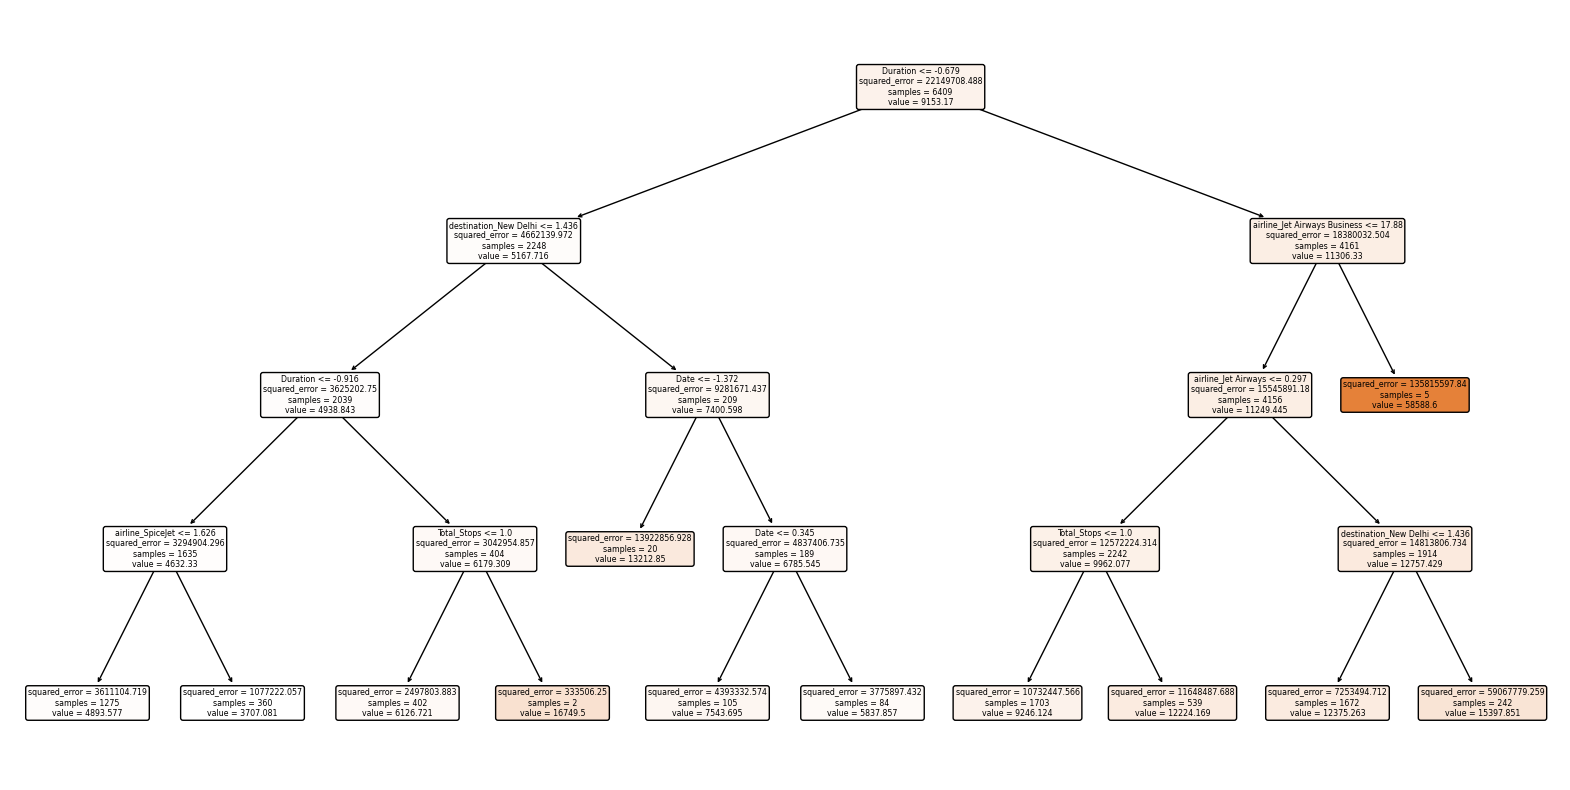

In [17]:
plt.figure(figsize=(20,10))
plot_tree(model, filled=True, feature_names=X_train.columns, rounded=True)
plt.show()

In [33]:
samples_rmse_train_list = []
samples_rmse_val_list = []

min_samples_split_list = np.linspace(2,300, 20).astype(int)
for min_samples_split in min_samples_split_list:
    model = RandomForestRegressor(min_samples_split=min_samples_split, random_state=42)
    model.fit(X_train_scaled, y_train)
    
    predictions_train = model.predict(X_train_scaled)
    predictions_val = model.predict(X_val_scaled)
    
    rmse_train = np.sqrt(mean_squared_error(y_train, predictions_train))
    rmse_val = np.sqrt(mean_squared_error(y_val, predictions_val))
    
    samples_rmse_train_list.append(rmse_train)
    samples_rmse_val_list.append(rmse_val)

In [34]:
depth_rmse_train_list = []
depth_rmse_val_list = []

max_depth_list = np.linspace(1,30,20).astype(int)
for max_depth in max_depth_list:
    model = RandomForestRegressor(max_depth = max_depth, random_state=42)
    model.fit(X_train_scaled, y_train)
    
    predictions_train = model.predict(X_train_scaled)
    predictions_val = model.predict(X_val_scaled)
    
    rmse_train = np.sqrt(mean_squared_error(y_train, predictions_train))
    rmse_val = np.sqrt(mean_squared_error(y_val, predictions_val))
    
    depth_rmse_train_list.append(rmse_train)
    depth_rmse_val_list.append(rmse_val)

Text(0, 0.5, 'RMSE')

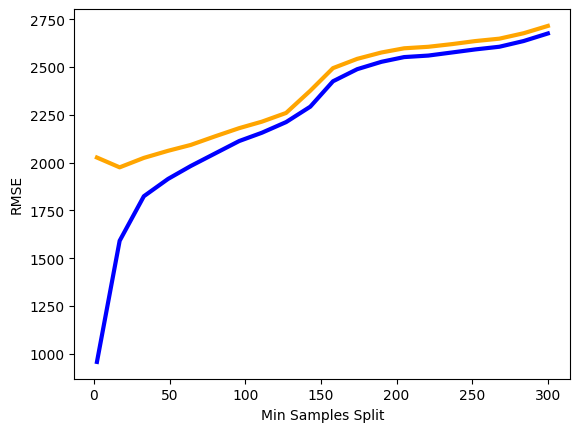

In [35]:
plt.plot(min_samples_split_list, samples_rmse_train_list, color = 'blue', linewidth = 3)
plt.plot(min_samples_split_list, samples_rmse_val_list, color = 'orange', linewidth = 3)
plt.xlabel('Min Samples Split')
plt.ylabel('RMSE')

Text(0, 0.5, 'RMSE')

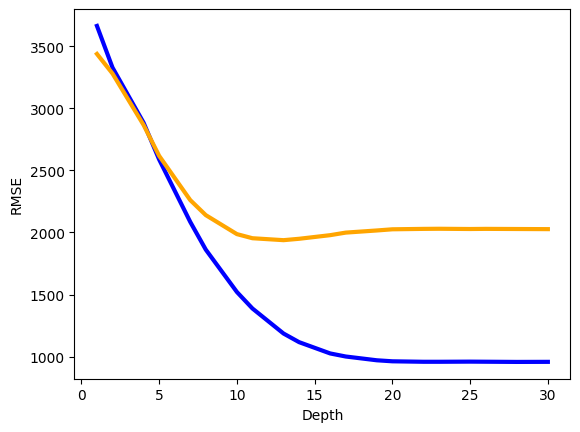

In [36]:
plt.plot(max_depth_list, depth_rmse_train_list, color = 'blue', linewidth = 3)
plt.plot(max_depth_list, depth_rmse_val_list, color = 'orange', linewidth = 3)
plt.xlabel('Depth')
plt.ylabel('RMSE')

min samples split = 60

max depth = 5

*************************************************************************
c переводом категориальных в числовые ('Airline', 'Source', 'Destination').

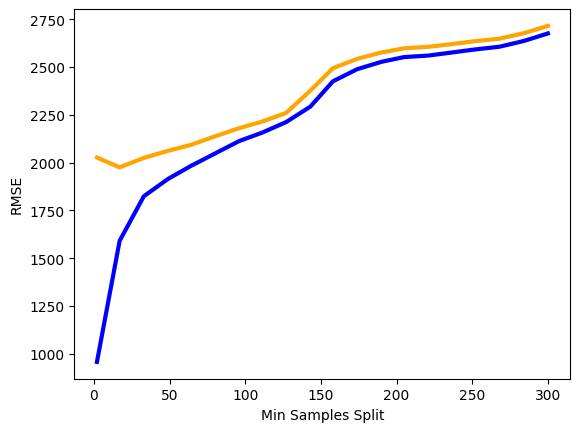 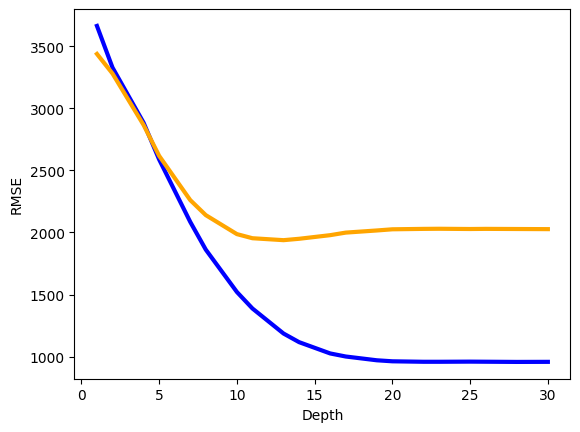

*************************************************************************

без перевода категориальных в числовые

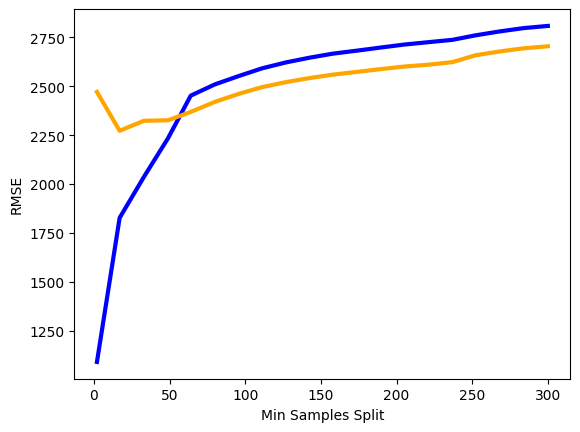 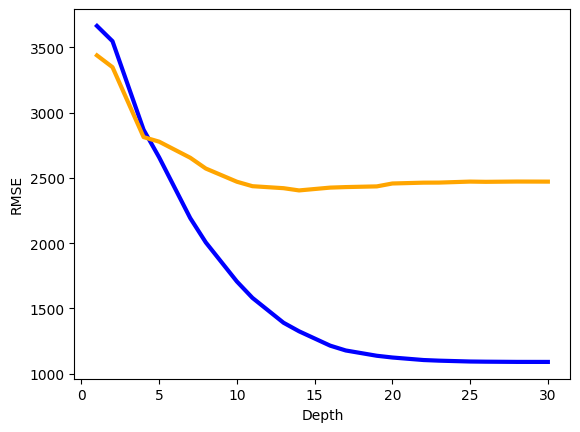

In [37]:
model = RandomForestRegressor(min_samples_split=60,max_depth=4,random_state=42)
model.fit(X_train_scaled, y_train)
y_pred_rf = model.predict(X_test_scaled)
print(f"Random forest model rmse: {np.sqrt(mean_squared_error(y_test, y_pred_rf))}")

Random forest model rmse: 2807.8164051482195


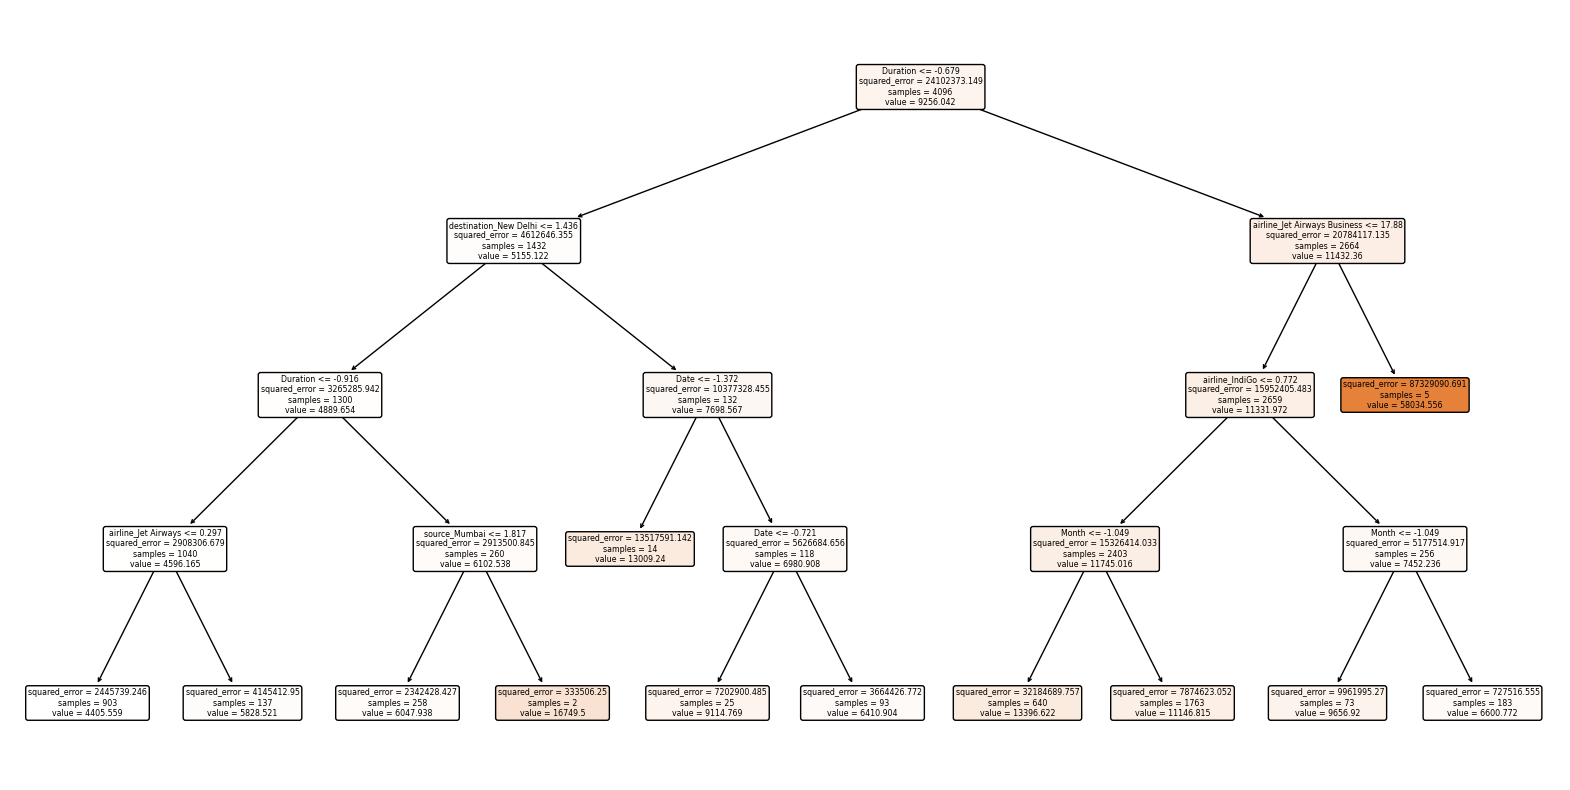

In [38]:
one_tree = model.estimators_[99]

plt.figure(figsize=(20,10))
plot_tree(one_tree, filled=True, feature_names=X_train.columns, rounded=True)
plt.show()

In [39]:
pd.DataFrame({'y_test': y_test,
                       'y_pred': y_pred_rf,
                       'Difference': abs(y_test - y_pred_rf)})

,y_test,y_pred,Difference
2063,10262,12564.996015,2302.996015
7923,10361,11922.350074,1561.350074
5517,4174,4307.987534,133.987534
5595,3873,4307.987534,434.987534
7136,13014,12623.944517,390.055483
...,...,...,...
8878,14571,12308.865761,2262.134239
6978,5224,4769.959039,454.040961
6060,3543,4236.340630,693.340630
5932,6991,8101.663167,1110.663167


In [40]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
from sklearn.metrics import mean_squared_error

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dense(64, activation='relu'),
    Dense(64, activation='sigmoid'),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
history = model.fit(X_train_scaled, y_train, epochs=10, batch_size=32, validation_data=(X_val_scaled, y_val))

y_pred_tf = model.predict(X_test_scaled)
y_pred_tf = y_pred_tf.flatten()

mse_tf = mean_squared_error(y_test, y_pred_tf)

rmse_tf = np.sqrt(mse_tf)

print(f"Tensorflow rmse: {rmse_tf}")

Epoch 1/10
201/201 [==============================] - 1s 3ms/step - loss: 92925232.0000 - val_loss: 54459580.0000
Epoch 2/10
201/201 [==============================] - 0s 2ms/step - loss: 26784900.0000 - val_loss: 9779461.0000
Epoch 3/10
201/201 [==============================] - 1s 2ms/step - loss: 10442920.0000 - val_loss: 7559611.0000
Epoch 4/10
201/201 [==============================] - 0s 2ms/step - loss: 9077075.0000 - val_loss: 6687371.5000
Epoch 5/10
201/201 [==============================] - 0s 2ms/step - loss: 8331135.5000 - val_loss: 6415470.0000
Epoch 6/10
201/201 [==============================] - 0s 2ms/step - loss: 7921593.5000 - val_loss: 5970976.0000
Epoch 7/10
201/201 [==============================] - 1s 3ms/step - loss: 7555374.5000 - val_loss: 5654646.5000
Epoch 8/10
201/201 [==============================] - 0s 2ms/step - loss: 7217722.5000 - val_loss: 5500190.0000
Epoch 9/10
201/201 [==============================] - 0s 2ms/step - loss: 6999370.0000 - val_loss: 5

Text(0, 0.5, 'Loss')

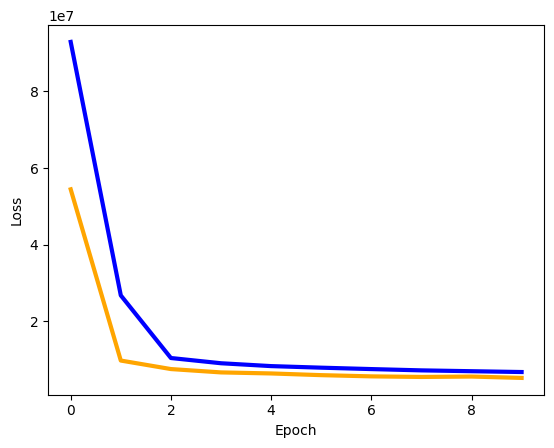

In [41]:
plt.plot(history.history['loss'], color = 'blue', linewidth = 3)
plt.plot(history.history['val_loss'], color = 'orange', linewidth = 3)
plt.xlabel('Epoch')
plt.ylabel('Loss')

In [42]:
pd.DataFrame({'y_test': y_test,
                       'y_pred': y_pred_tf,
                       'Difference': abs(y_test - y_pred_tf)})

,y_test,y_pred,Difference
2063,10262,12093.926758,1831.926758
7923,10361,12281.478516,1920.478516
5517,4174,3968.811523,205.188477
5595,3873,3888.845703,15.845703
7136,13014,13951.819336,937.819336
...,...,...,...
8878,14571,12439.795898,2131.204102
6978,5224,4359.128418,864.871582
6060,3543,4005.003906,462.003906
5932,6991,5609.038086,1381.961914


In [18]:
model = AdaBoostRegressor(learning_rate=0.1, random_state=42)
model.fit(X_train_scaled, y_train)
y_pred_ab = model.predict(X_test_scaled)
print(f"AdaBoostRegressor tree model rmse: {np.sqrt(mean_squared_error(y_test, y_pred_ab))}")

Decision tree model rmse: 3074.2979090276913


In [54]:
model = GradientBoostingRegressor(learning_rate=0.1, min_samples_split=60,max_depth=7,random_state=42)
model.fit(X_train_scaled, y_train)
y_pred_gb = model.predict(X_test_scaled)
print(f"GradientBoostingRegressor tree model rmse: {np.sqrt(mean_squared_error(y_test, y_pred_gb))}")

Decision tree model rmse: 1751.6920447847858


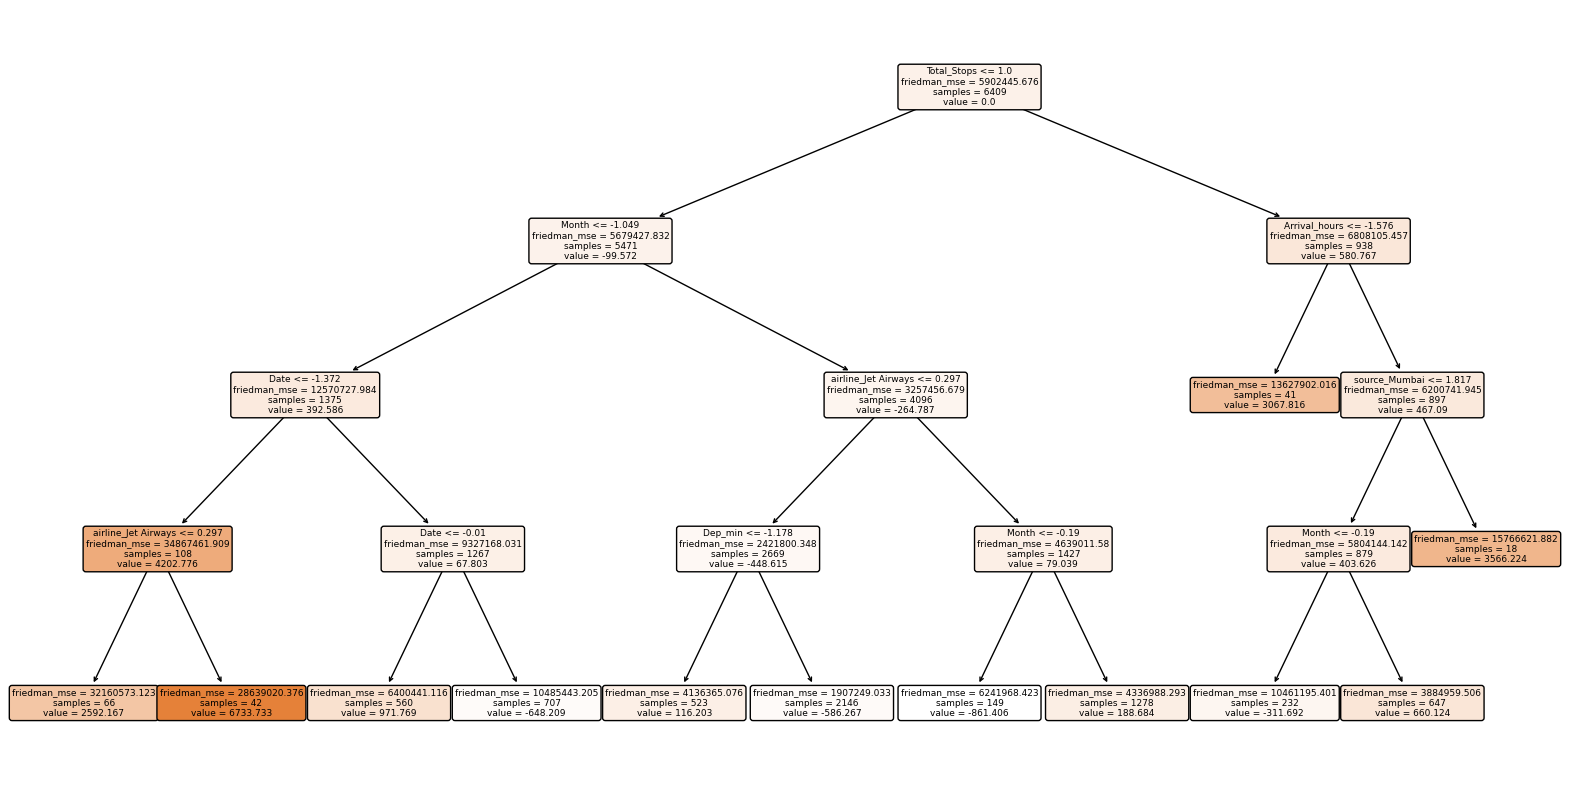

In [38]:
one_tree = model.estimators_[25, 0]

plt.figure(figsize=(20,10))
plot_tree(one_tree, filled=True, feature_names=X_train.columns, rounded=True)
plt.show()

In [21]:
pd.DataFrame({'y_test': y_test,
                       'y_pred': y_pred_gb,
                       'Difference': abs(y_test - y_pred_gb)})

,y_test,y_pred,Difference
2063,10262,12080.880776,1818.880776
7923,10361,11822.255909,1461.255909
5517,4174,4177.124704,3.124704
5595,3873,3895.540413,22.540413
7136,13014,13228.619917,214.619917
...,...,...,...
8878,14571,12901.895328,1669.104672
6978,5224,4801.370561,422.629439
6060,3543,4248.025350,705.025350
5932,6991,6384.388744,606.611256


In [56]:
model = xgb.XGBRegressor(learning_rate=0.1, max_depth=7, random_state=42)
model.fit(X_train_scaled, y_train)
y_pred_xgb = model.predict(X_test_scaled)
print(f"XGBRegressor tree model rmse: {np.sqrt(mean_squared_error(y_test, y_pred_xgb))}")

Decision tree model rmse: 1727.7101193489598


<Figure size 1e+06x1e+06 with 0 Axes>

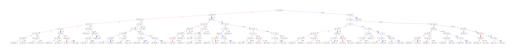

In [58]:
import graphviz

booster = model.get_booster()

# graph_data = xgb.to_graphviz(booster, num_trees=2)
# graph_data.view()

plt.figure(figsize=(100, 100))
xgb.plot_tree(booster, num_trees=2, fmap='', rankdir='UT')
plt.show()